In [103]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud, STOPWORDS

# Data import

In [104]:
data1 = pd.read_csv('data/UFO.csv')
data2 = pd.read_csv('data/NewUFO.csv')
data = data1.append(data2, ignore_index=True)
print(f"The shape is {data.shape}")
data.head()

The shape is (103938, 9)


/var/folders/wz/8n_4nrc10ksftqym5ltn56xw0000gn/T/ipykernel_16859/2084718926.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  data = data1.append(data2, ignore_index=True)


,Unnamed: 0,0,1,2,3,4,5,6,7
0,0,23:00,12/19/21,Branford,CT,Circle,NaN,See craft every evening when I get out of work...,12/19/21
1,1,00:15,12/19/21,Deltona,FL,Changing,"1 minute, 9 seconds video",I was on Ring app in house and saw incredible ...,12/19/21
2,2,21:45,12/18/21,Long Beach,CA,Triangle,3-5 seconds,3 Boomerang shaped craft flying in formation,12/19/21
3,3,00:00,12/18/21,Charlotte,NC,Cigar,still active 12:35am,"flying stick, the ends of it brighter. Recorde...",12/19/21
4,4,23:30,12/17/21,Traver,CA,Oval,2 hours,((HOAX)) near the Foster farms feed mill in Tr...,12/19/21


# Setting column names

In [105]:
labels = ["NA",'Time', 'Date', 'City', 'State', 'Shape', 'Duration', 'Summary', 'Posted']
data.set_axis(labels, axis=1, inplace=True)
data = data.drop(columns=["NA", "Posted"])
data.head()

# This is important to be peformed at this point
data["Time"] = pd.to_datetime(data["Time"],errors='coerce').dt.hour
data["Date"] = pd.to_datetime(data["Date"], errors='coerce')

/var/folders/wz/8n_4nrc10ksftqym5ltn56xw0000gn/T/ipykernel_16859/988337354.py:2: FutureWarning: DataFrame.set_axis 'inplace' keyword is deprecated and will be removed in a future version. Use `obj = obj.set_axis(..., copy=False)` instead
  data.set_axis(labels, axis=1, inplace=True)
/var/folders/wz/8n_4nrc10ksftqym5ltn56xw0000gn/T/ipykernel_16859/988337354.py:8: UserWarning: Parsing dates in DD/MM/YYYY format when dayfirst=False (the default) was specified. This may lead to inconsistently parsed dates! Specify a format to ensure consistent parsing.
  data["Date"] = pd.to_datetime(data["Date"], errors='coerce')


# Clearing all null values

In [106]:
print("Null Values")
display(data.isnull().sum())

data.dropna(inplace=True)

print("Null Values Now")
data.isnull().sum()

Null Values


Time          75
Date        1701
City         519
State       7881
Shape       4872
Duration    4537
Summary       64
dtype: int64

Null Values Now


Time        0
Date        0
City        0
State       0
Shape       0
Duration    0
Summary     0
dtype: int64

# Handling duplicates

In [107]:
print(f"Duplicates - {data.duplicated().sum()}")
data.drop_duplicates(inplace=True)
print(f"Duplicates Now - {data.duplicated().sum()}")

Duplicates - 11
Duplicates Now - 0


# Converting dtypes

In [108]:
print("Data dtypes")
display(data.dtypes)

data["City"] = data["City"].astype("category")
data["State"] = data["State"].astype("category")
data["Shape"] = data["Shape"].astype("string")
data["Duration"] = data["Duration"].astype("string")
data["Summary"] = data["Summary"].astype("string")

print("Data dtypes now")
data.dtypes

Data dtypes


Time               float64
Date        datetime64[ns]
City                object
State               object
Shape               object
Duration            object
Summary             object
dtype: object

Data dtypes now


Time               float64
Date        datetime64[ns]
City              category
State             category
Shape               string
Duration            string
Summary             string
dtype: object

# Data Standardization/Transformation

In [109]:
data["Day"] = data["Date"].dt.day
data["Month"] = data["Date"].dt.month
data["Year"] = data["Date"].dt.year

data = data.drop(columns="Date")
data = data[data["Year"] < 2025]

columns = ["Time", "Day", "Month", "Year", "City", "State", "Shape", "Duration", "Summary"]
data = data[columns]

data.head()

,Time,Day,Month,Year,City,State,Shape,Duration,Summary
1,0.0,19,12,2021,Deltona,FL,Changing,"1 minute, 9 seconds video",I was on Ring app in house and saw incredible ...
2,21.0,18,12,2021,Long Beach,CA,Triangle,3-5 seconds,3 Boomerang shaped craft flying in formation
3,0.0,18,12,2021,Charlotte,NC,Cigar,still active 12:35am,"flying stick, the ends of it brighter. Recorde..."
4,23.0,17,12,2021,Traver,CA,Oval,2 hours,((HOAX)) near the Foster farms feed mill in Tr...
5,22.0,17,12,2021,Butte,MT,Circle,15 minutes,Saw orb that moved around the moon and got pic...


### The variable "Shape" has to be standardized. There are also same-values that are spelled differently.

In [110]:
shapeValueCount = data.Shape.value_counts().index
display(data.Shape.value_counts().index)

for elements in shapeValueCount:
    if elements[0].isupper() == True:
        lowered = elements.lower()
        data['Shape'] = data.Shape.apply(lambda x : elements if x.lower() == lowered else x)
data['Shape'] = data.Shape.apply(lambda x : 'Triangle' if x == 'TRIANGULAR' else x)
data['Shape'] = data.Shape.apply(lambda x : 'Changing' if x == 'changed' else x)

data.Shape.value_counts().index

Index(['Light', 'Circle', 'Triangle', 'Other', 'Unknown', 'Fireball', 'Sphere',
       'Disk', 'Oval', 'Formation', 'Changing', 'Cigar', 'Flash', 'Rectangle',
       'Cylinder', 'Diamond', 'Chevron', 'Teardrop', 'Egg', 'Cone', 'Cross',
       'light', 'other', 'triangle', 'circle', 'Delta', 'sphere', 'cylinder',
       'rectangle', 'cigar', 'Crescent', 'diamond', 'oval', 'fireball',
       'Round', 'CA', 'egg', 'Hexagon', 'Early', 'Flare', 'changing', 'flash',
       'unknown', 'OH', 'Jacksonville', 'changed', 'delta', 'TRIANGULAR',
       'Summer', 'pyramid'],
      dtype='string')

Index(['Light', 'Circle', 'Triangle', 'Other', 'Unknown', 'Fireball', 'Sphere',
       'Disk', 'Oval', 'Formation', 'Changing', 'Cigar', 'Flash', 'Rectangle',
       'Cylinder', 'Diamond', 'Chevron', 'Teardrop', 'Egg', 'Cone', 'Cross',
       'Delta', 'Round', 'CA', 'Crescent', 'Flare', 'Hexagon', 'Jacksonville',
       'Summer', 'OH', 'Early', 'pyramid'],
      dtype='object')

### Here all invalid states are removed

In [111]:
validStates = [
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
    'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
    'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
    'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
    'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY'
]

data["State"] = data["State"].astype("string")
display(data.State.value_counts().index)

data = data[data["State"].isin(validStates)]

data["State"] = data["State"].astype("category")
data.State.value_counts().index

Index(['CA', 'FL', 'WA', 'TX', 'NY', 'AZ', 'PA', 'IL', 'OH', 'MI', 'OR', 'NC',
       'CO', 'MO', 'NJ', 'GA', 'VA', 'ON', 'MA', 'WI', 'IN', 'TN', 'MN', 'SC',
       'NV', 'MD', 'CT', 'KY', 'NM', 'UT', 'OK', 'BC', 'AL', 'ID', 'AR', 'KS',
       'IA', 'ME', 'LA', 'NH', 'MT', 'WV', 'MS', 'AB', 'NE', 'HI', 'RI', 'AK',
       'VT', 'WY', 'DE', 'SD', 'QC', 'MB', 'ND', 'NS', 'SK', 'NB', 'DC', 'PQ',
       'NF', 'SA', 'PR', 'YT', 'NT', 'PE', 'YK', 'Ca', 'Ontario (Canada)',
       'County Waterford', 'USVI', 'Ontario', 'Warrington', 'M0', 'March',
       'Las Palmas Province', 'Los Angeles (Hollywood Hills, north of)',
       '1965', 'October', 'University Heights', 'Michigan Bar', 'VI'],
      dtype='string')

CategoricalIndex(['CA', 'FL', 'WA', 'TX', 'NY', 'AZ', 'PA', 'IL', 'OH', 'MI',
                  'OR', 'NC', 'CO', 'MO', 'NJ', 'GA', 'VA', 'MA', 'WI', 'IN',
                  'TN', 'MN', 'SC', 'NV', 'MD', 'CT', 'KY', 'NM', 'UT', 'OK',
                  'AL', 'ID', 'AR', 'KS', 'IA', 'ME', 'LA', 'NH', 'MT', 'WV',
                  'MS', 'NE', 'HI', 'RI', 'AK', 'VT', 'WY', 'DE', 'SD', 'ND'],
                 categories=[AK, AL, AR, AZ, ..., WA, WI, WV, WY], ordered=False, dtype='category')

### The city of the location has many arbitrary value so we will drop it

In [112]:
count = len(data["City"].value_counts())
print(f"Unique values for City column - {count}")

data = data.drop(columns=["City"])
data.head()

Unique values for City column - 18852


,Time,Day,Month,Year,State,Shape,Duration,Summary
1,0.0,19,12,2021,FL,Changing,"1 minute, 9 seconds video",I was on Ring app in house and saw incredible ...
2,21.0,18,12,2021,CA,Triangle,3-5 seconds,3 Boomerang shaped craft flying in formation
3,0.0,18,12,2021,NC,Cigar,still active 12:35am,"flying stick, the ends of it brighter. Recorde..."
4,23.0,17,12,2021,CA,Oval,2 hours,((HOAX)) near the Foster farms feed mill in Tr...
5,22.0,17,12,2021,MT,Circle,15 minutes,Saw orb that moved around the moon and got pic...


#

# Analysis

#

## Distribution showing which state had the most recorded UFO sightings

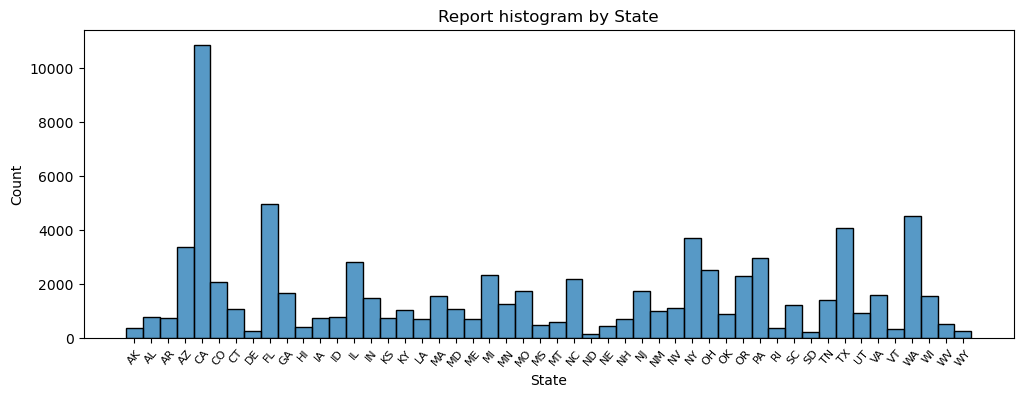

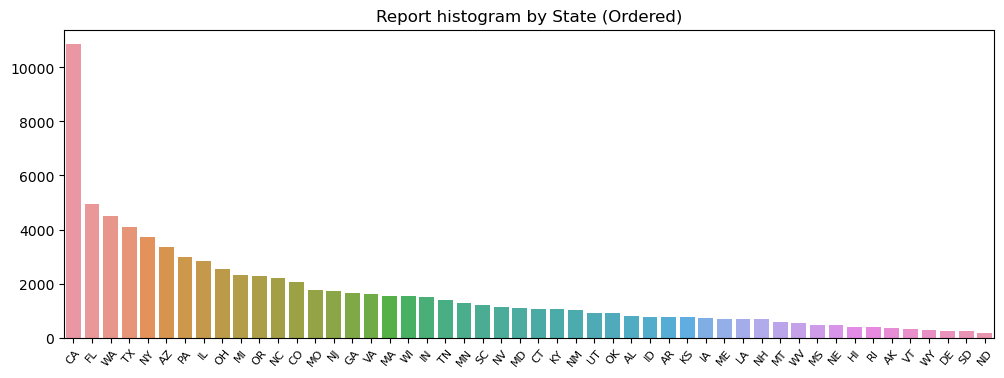

In [138]:
plt.figure(figsize=(12,4))
sns.histplot(x="State", data=data)
plt.title("Report histogram by State")
plt.xticks(rotation=50, fontsize=8)

x = data.State.value_counts().index.tolist()
y = data.State.value_counts().values.tolist()

plt.figure(figsize=(12,4))
sns.barplot(x=x, y=y)
plt.title("Report histogram by State (Ordered)")
plt.xticks(rotation=50, fontsize=8)

plt.show()

# 

## Distribution showing what time, day, month and year had the most recorded UFO sightings

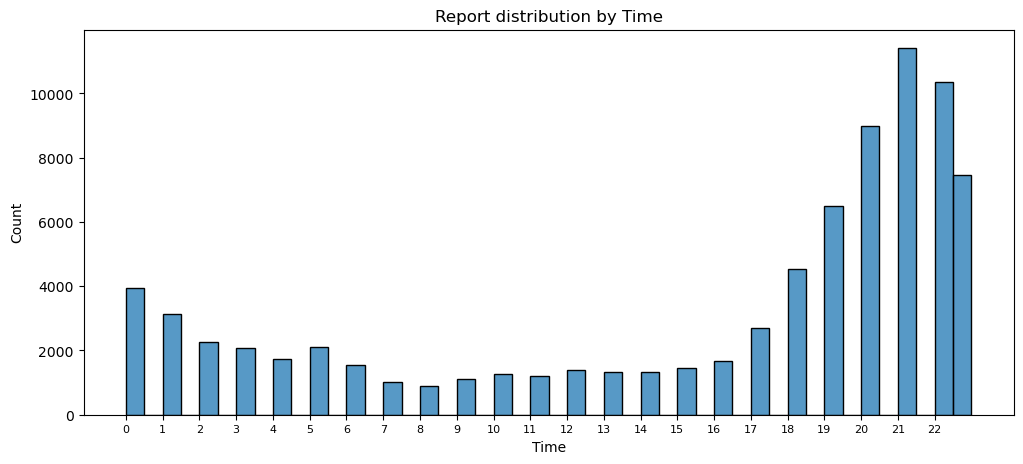

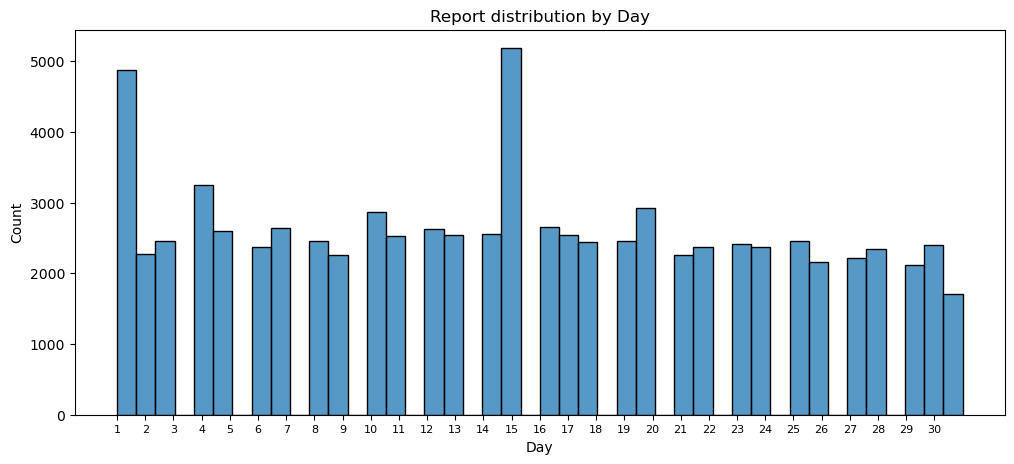

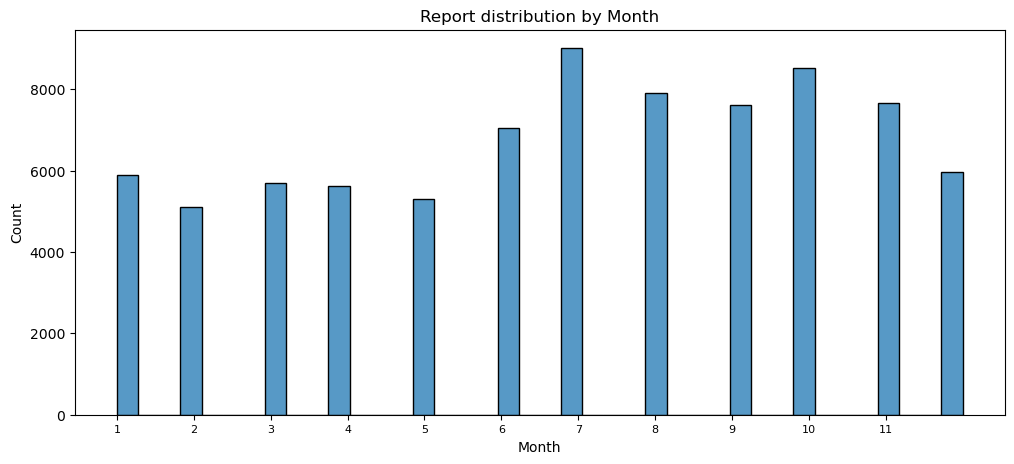

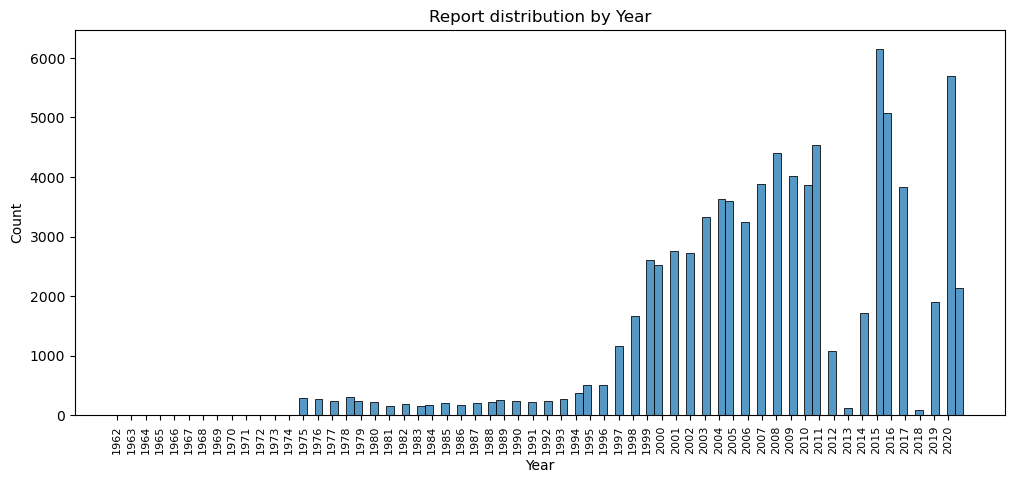

In [135]:
columns = ["Time", "Day", "Month", "Year"]

for column in columns:
    plt.figure(figsize=(12,5))
    sns.histplot(x=column, data=data)
    plt.title(f"Report distribution by {column}")
    
    minValue = min(data[column])
    maxValue = max(data[column])
    plt.xticks(np.arange(minValue, maxValue, 1), rotation=90 if column=="Year" else 0, fontsize=8)


plt.show()

## Distribution showing the most commonly seen shape when witnessing a UFO

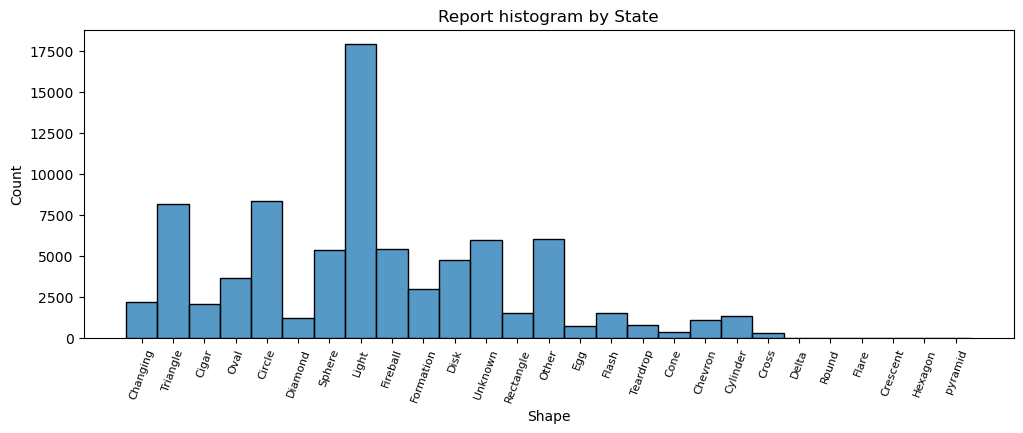

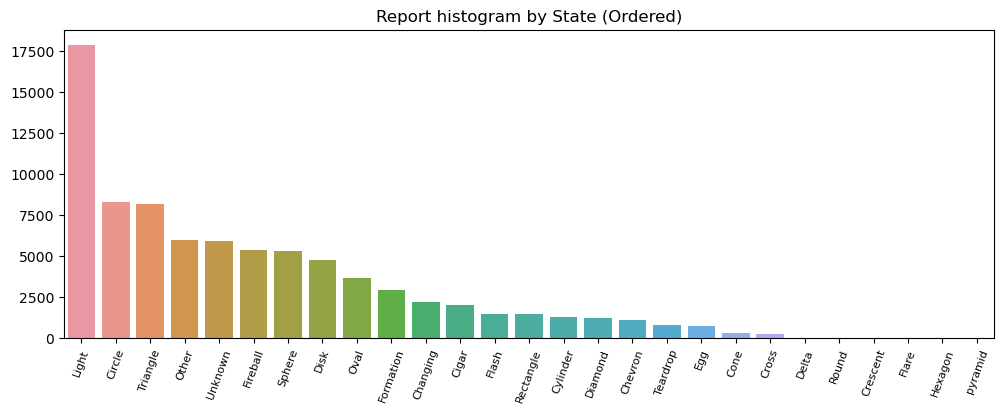

In [139]:
plt.figure(figsize=(12,4))
sns.histplot(x="Shape", data=data)
plt.title("Report histogram by State")
plt.xticks(rotation=70, fontsize=8)

x = data.Shape.value_counts().index.tolist()
y = data.Shape.value_counts().values.tolist()

plt.figure(figsize=(12,4))
sns.barplot(x=x, y=y)
plt.title("Report histogram by State (Ordered)")
plt.xticks(rotation=70, fontsize=8)

plt.show()

#

# Wordclouds

# 

## The most common words used in the summary of the UFO report

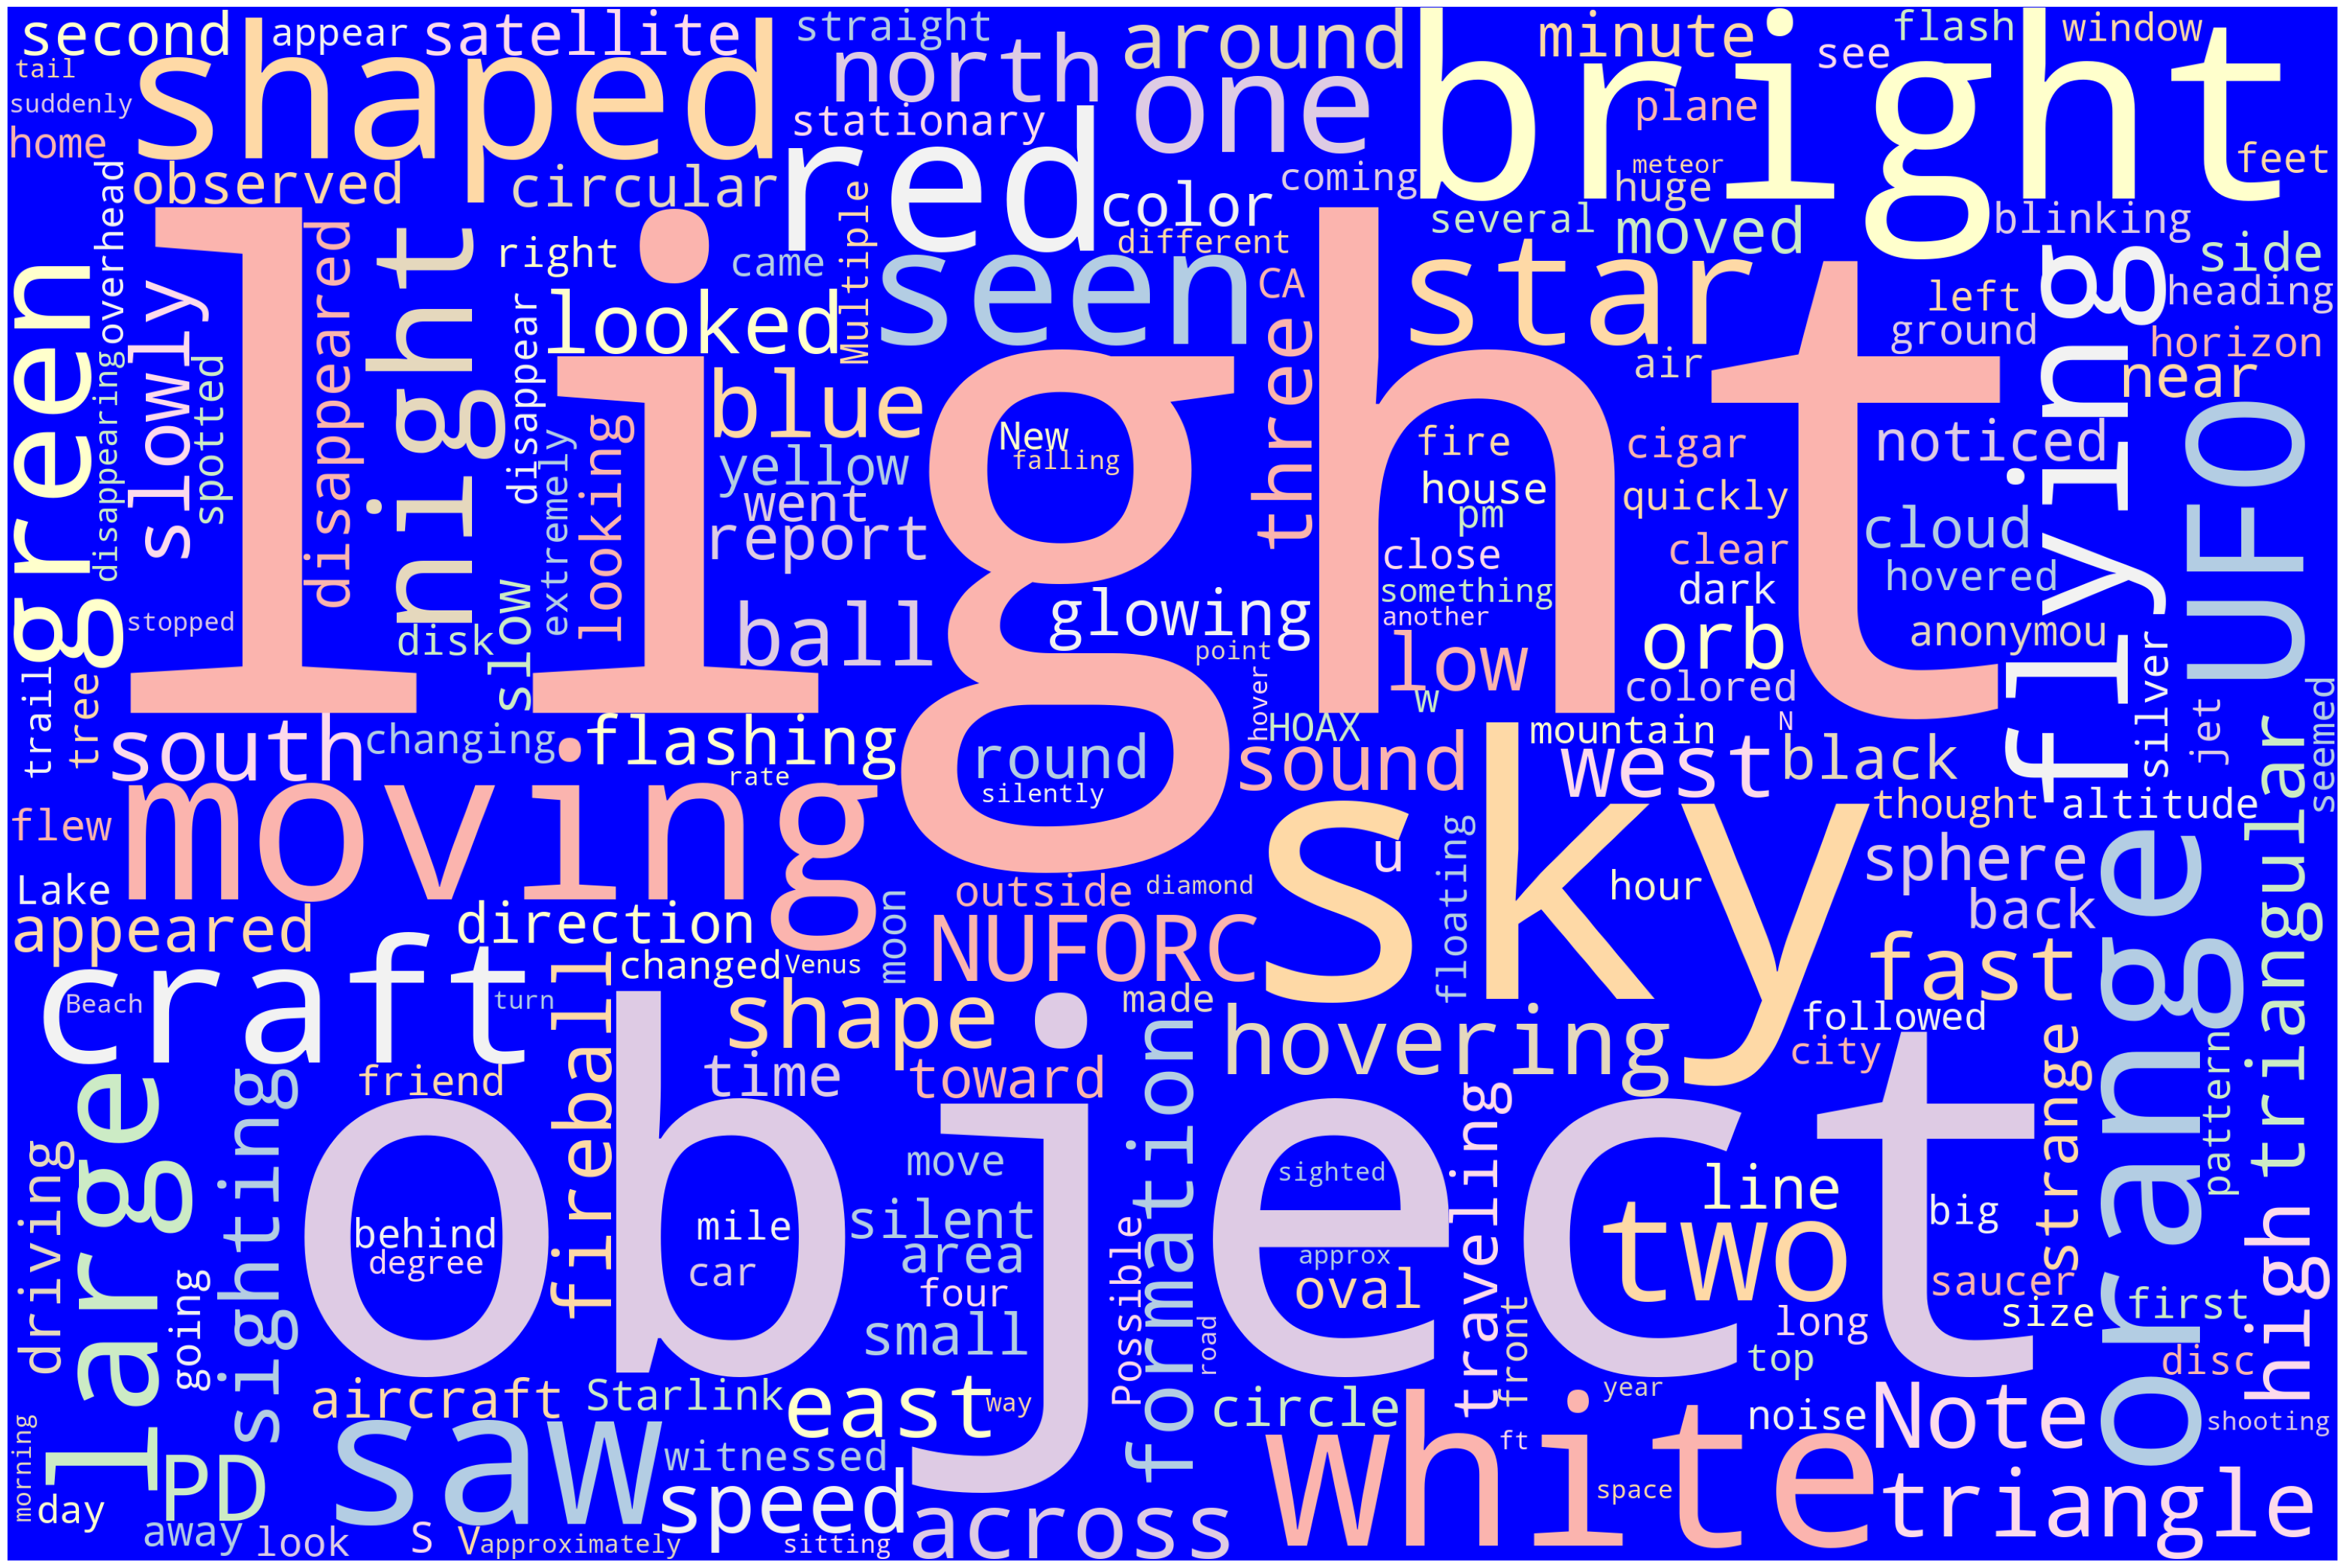

In [169]:
text = ' '.join(x for x in data['Summary'])

wordcloud = WordCloud(width= 3000, height = 2000, random_state=1, 
                      background_color='blue', colormap='Pastel1', 
                      collocations=False, stopwords = STOPWORDS).generate(text)

plt.figure(figsize=(40, 30))
plt.imshow(wordcloud) 
plt.axis("off");
plt.show()

## The most common words used when conveying the duration of the UFO sighting

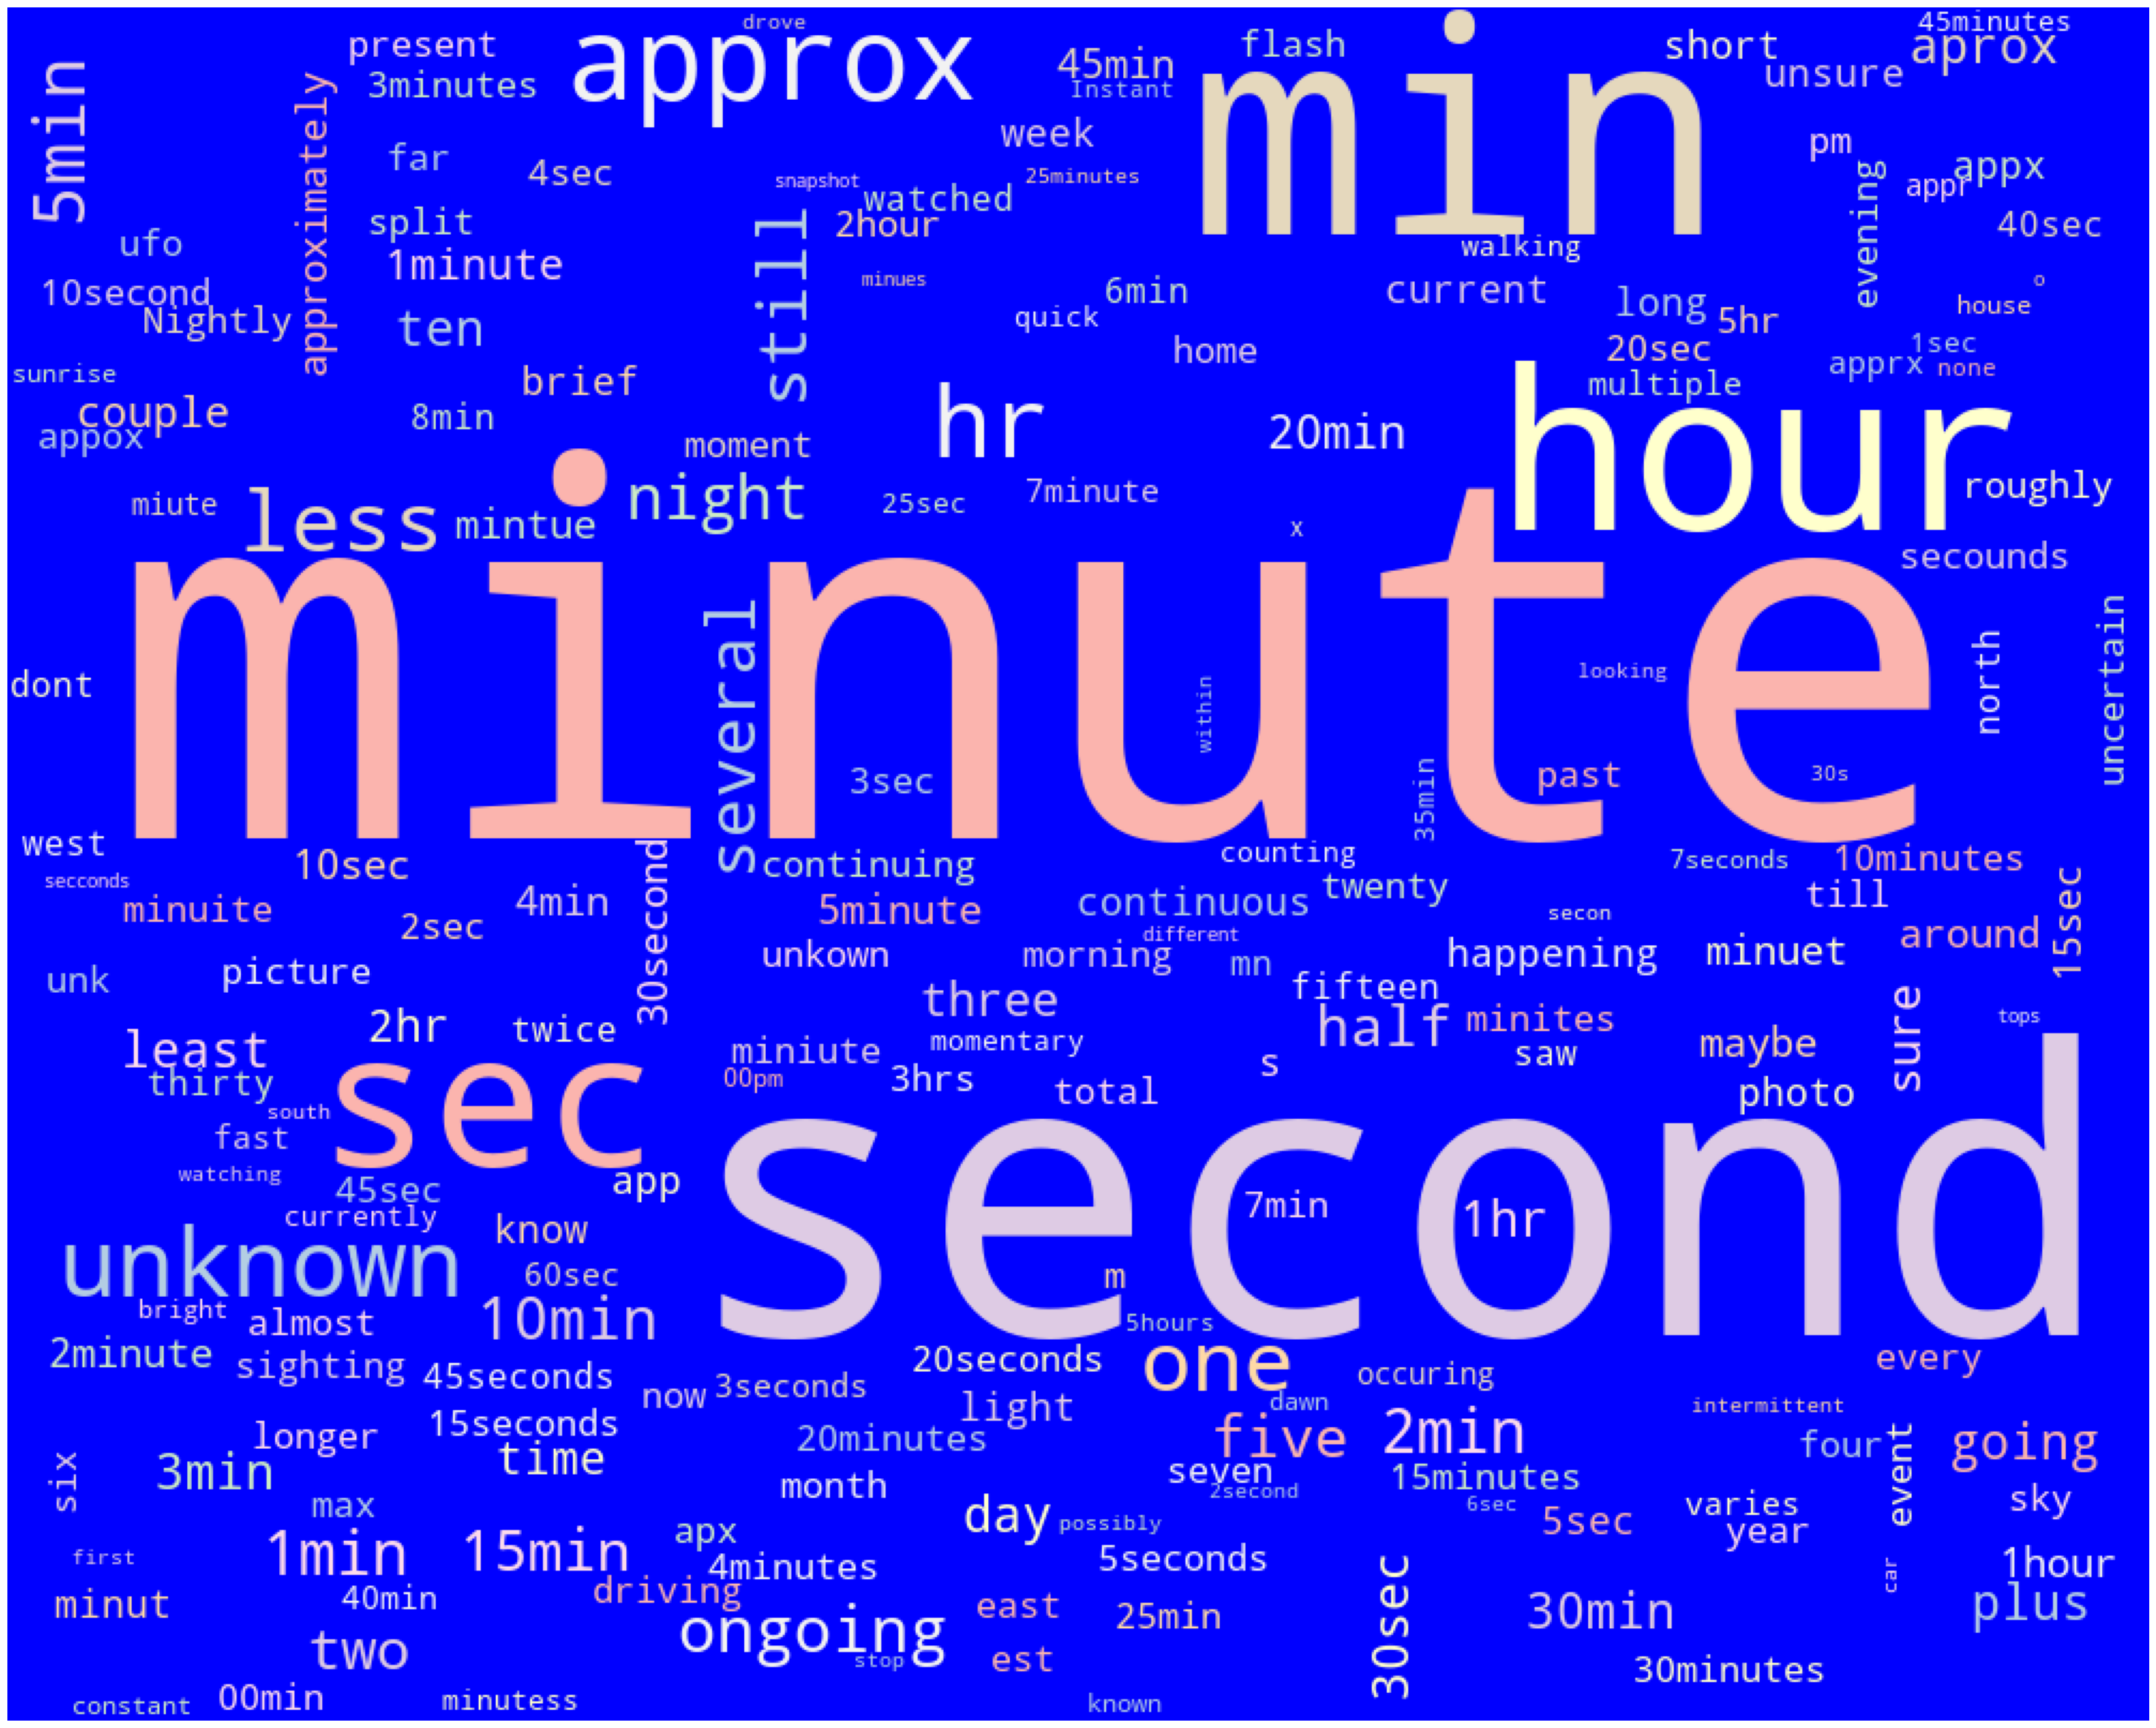

In [171]:
text = ' '.join(x for x in data['Duration'])

wordcloud = WordCloud(width= 1000, height = 800, random_state=1, 
                      background_color='blue', colormap='Pastel1', 
                      collocations=False, stopwords = STOPWORDS).generate(text)

plt.figure(figsize=(40, 30))
plt.imshow(wordcloud) 
plt.axis("off");
plt.show()